In [9]:
# Essential functions for changing the coords

##############################################################################
"""
trajframe.py

Description:
Defines the TrajFrame Class from a DataFrame or LazyFrame containing atmosphere
ocean parcel trajectories (and accompanying tracers) stored in a tabular format.
"""
##############################################################################
# Import relevant packages.
import os
import numpy as np
import polars as pl
import xarray as xr
import plotly.express as px

# Import types:
from typing_extensions import Self



##############################################################################
# Define TrajFrame Class.


class TrajFrame:
    """
    Create a TrajFrame from Lagrangian trajectories stored in either a
    polars DataFrame or LazyFrame or an xarray DataSet.

    Parameters
    ----------
    source: DataFrame | LazyFrame | DataSet
        Lagrangian trajectories to be stored in TrajFrame.
        Trajectories specified in eager or lazy tabular data formats
        can be stored in long-format or condensed formats.
        Trajectories specified in an xarray DataSet will be transformed
        to a condensed DataFrame before TrajFrame creation. 
    condense: bool, default: False
        Transform DataFrame or LazyFrame from long-format to condensed
        format where data is stored in list columns.
    rename_cols : dict, default: None
        Rename columns variables using key value pairs that map from
        current to new column names.
    summary_source : DataSet, default: None
        DataSet storing summary statistics in the form of n-dimensional 
        DataArrays generated from Lagrangian trajectory data contained in
        the TrajFrame.

    Returns
    --------
    TrajFrame
        Complete trajectories, including all column variables contained
        in .data attribute. Summary statistics stored as n-dimensional
        arrays in .summary_data.

    Examples
    --------
    Creating TrajFrame, trajectories, with example_trajectories.csv file in eager mode.

    >>> filename = 'example_trajectories.csv'
    >>> data = pl.read_csv(filename)
    >>> trajectories = TrajFrame(source=data)

    Creating TrajFrame, trajectories, with multiple parquet files in lazy mode.

    >>> filenames = [ 'example_trajectories1.parquet', 'example_trajectories2.parquet']
    >>> data = pl.concat([pl.scan_csv(file) for file in filenames])
    >>> trajectories = TrajFrame(source=data)

    Creating TrajFrame, trajectories, from a .zarr file with dimensions (traj x obs).
    The water parcel IDs must be stored in a 2-dimensional array, trajectory. When
    creating a TrajFrame from a DataSet, condense is defined as True by default.

    >>> filename = 'example_trajectories.zarr'
    >>> dataset = xr.open_zarr(filename, chunks=None)
    >>> trajectories = TrajFrame(source=dataset, condense=True)
    """


def __init__(self,
                 source:pl.DataFrame | pl.LazyFrame | xr.Dataset,
                 condense:bool=False,
                 rename_cols:dict | None=None,
                 summary_source:xr.Dataset | None=None
                 ):
        # -------------------
        # Raising exceptions:
        # -------------------
        # Determine if source is Polars DataFrame:
        is_dataframe = isinstance(source, pl.DataFrame)
        # Determine if source is Polars LazyFrame:
        is_lazyframe = isinstance(source, pl.LazyFrame)
        # Determine if source is xarray DataSet:
        is_dataset = isinstance(source, xr.Dataset)

        # Raise error if source is not a Polars DataFrame / LazyFrame:
        if (is_dataframe | is_lazyframe | is_dataset) is False:
            raise TypeError("source must be specified as an xarray DataSet or polars DataFrame or LazyFrame")

        # Raise error if condense is not a boolean:
        if isinstance(condense, bool) is False:
            raise TypeError("condense must be specified as a boolean")

        # Raise error if summary_source is not an xarray DataSet:
        if summary_source is not None:
            if isinstance(summary_source, xr.Dataset) is False:
                raise TypeError("summary_source must be specified an xarray DataSet")

        # Raise error if attrs is not a dictionary:
        if rename_cols is not None:
            if isinstance(rename_cols, dict) is False:
                raise TypeError("rename columns mapping specified as a dictionary")

        # Raise error if trajectory and obs coords not present in xarray DataSet:
        if is_dataset:
            coord_list = list(source.coords)
            if 'trajectory' not in coord_list:
                raise ValueError("\'trajectory\' must be specified as a coordinate in the xarray DataSet")
            if 'obs' not in coord_list:
                raise ValueError("\'obs\' must be specified as a coordinate in the xarray DataSet")

        # ----------------------------------------------
        # Constructing Lagrangian TrajFrame from source:
        # ----------------------------------------------
        if is_dataset:
            # Define condense as True by default:
            condense = True
            # Transforming xarray DataSet to Dask DataFrame:
            df_dask = (source
                       .to_dask_dataframe(dim_order=['trajectory', 'obs'], set_index=False)
                       .dropna()
                       .drop(columns='obs')
                       .rename(columns={'trajectory':'id'})
                       )
            # Defining polars Dataframe from xarray DataSet:
            source = (pl.from_pandas(df_dask.compute()))

        # Renaming column variables of TrajFrame:
        if rename_cols is not None:
            # Rename column variables using key value pairs that map from
            # old name to new name:
            data = source.rename(rename_cols)
        else:
            data = source

        # Condense DataFrame / LazyFrame into list columns:
        if condense:
            data = (data
                    .group_by(pl.col('id'), maintain_order=True)
                    .agg([
                        pl.all()
                        ])
                    )

        # -----------------------------------------------------
        # Storing input DataFrame/LazyFrame as data attribute.
        # -----------------------------------------------------
        # Defining TrajFrame as input DataFrame or LazyFrame
        # containing one or more rows per trajectory.
        self.data = data
        # Add schema attribute to TrajFrame:
        self.schema = data.schema

        # ---------------------------------------
        # Defining modes as TrajFrame attributes:
        # ---------------------------------------
        # Defining mode of TrajFrame:
        if is_dataframe | is_dataset:
            self.traj_mode = 'eager'
        elif is_lazyframe:
            self.traj_mode = 'lazy'

        # --------------------------------------------
        # Storing summary_data as TrajFrame attribute.
        # --------------------------------------------
        if summary_source is not None:
            # Defining summary_data from specified Dataset.
            self.summary_data = summary_source
        elif summary_source is None:
            # Defining summary_data as empty Dataset.
            self.summary_data = xr.Dataset()

        # --------------------------------------
        # Extracting TrajFrame column variables.
        # --------------------------------------
        # Storing list of column variables contained in TrajFrame.
        self.columns = self.data.columns

        # Raise error if any core column variables are absent from TrajFrame.
        if 'id' not in self.columns:
            raise ValueError("core variable missing from TrajFrame: \'id\'")
        if 'time' not in self.columns:
            raise ValueError("core variable missing from TrajFrame: \'time\'")

        # ----------------------------------------------------
        # Storing LazyFrame query plan as TrajFrame attribute:
        # ----------------------------------------------------
        # Query plan for TrajFrame:
        if self.traj_mode == 'lazy':
            # Store optimised query plan description as query_plan:
            self.traj_query_plan = self.data.explain()
        else:
            # No query plan when using eager mode:
            self.traj_query_plan = None


##############################################################################
# Define print() method.

def __str__(self) -> str:
        # Return summary of TrajFrame object.

        # Construct summary string for TrajFrame:
        if self.traj_mode == 'eager':
            traj_str = f"<TrajFrame object>\n\n----- Trajectory DataFrame -----\nTrajectories: {self.data.shape[0]}\nVariables: {self.columns}\n{self.data.glimpse}\n"
        elif self.traj_mode == 'lazy':
            traj_str = f"<TrajFrame object>\n\n----- Trajectory LazyFrame -----\nSchema: {self.data.schema}\nOptimised Query Plan:\n{self.traj_query_plan}\n"

        return traj_str  

##############################################################################
# Define repr() method.

def __repr__(self) -> str:
        # Return summary of TrajFrame object.

        # Construct summary string for TrajFrame:
        if self.traj_mode == 'eager':
            traj_str = f"<TrajFrame object>\n\n----- Trajectory DataFrame -----\nTrajectories: {self.data.shape[0]}\nVariables: {self.columns}\n{self.data.glimpse}\n"
        elif self.traj_mode == 'lazy':
            traj_str = f"<TrajFrame object>\n\n----- Trajectory LazyFrame -----\nSchema: {self.data.schema}\nOptimised Query Plan:\n{self.traj_query_plan}\n"

        return traj_str

##############################################################################
# Define len() method.

def __len__(self) -> int:
        # Return the total number of trajectories in TrajFrame:
        if self.traj_mode == 'eager':
            len_str = self.data.shape[0]
        elif self.traj_mode == 'lazy':
            len_str = self.data.select(pl.count()).collect(streaming=True)

        return len_str

##############################################################################
# Define collect() method.

def collect(self,
                streaming:bool=False,
                **kwargs
                ) -> Self:
        """
        Execute LazyFrame optimised query and collect DataFrame.

        Parameters
        ----------
        streaming : bool, default: False
            Run parts of the query concurrently with streaming.
        **kwargs (optional)
            Additional keyword arguments to be passed to Polars collect() function.

        Returns
        --------
        TrajFrame
            TrajFrame is returned as an eager DataFrame following query execution.

        Examples
        --------
        Execute and collect the Lagrangian trajectories resulting from a simple
        filter without implementing streaming:

        >>> trajectories.filter('id < 100').collect(streaming=False)
        """
        # -------------------
        # Raising exceptions.
        # -------------------
        if isinstance(self.data, pl.LazyFrame) is False:
            raise TypeError("Lagrangian trajectories are not stored in a LazyFrame")
        if isinstance(streaming, bool) is False:
            raise TypeError("streaming must be specified as a boolean")

        # ------------------------------------------------------------
        # Collect LazyFrame(s) as DataFrame following query execution.
        # ------------------------------------------------------------
        # Execute optimised query plan on trajectory frame.
        trajectory_data = self.data.collect(streaming=streaming, **kwargs)

        # Return TrajFrame object including eager DataFrame:
        return TrajFrame(source=trajectory_data, summary_source=self.summary_data)

##############################################################################
# Define use_datetime.


def use_datetime(self,
                     start_date:str,
                     unit:str='s',
                     fmt:str="%Y-%m-%d"
                     ) -> Self:
        """
        Convert time column variable to Datetime format.

        Parameters
        ----------
        start_date : str
            Starting date to use when converting time column variable to Datetime.
        unit : str, default: 's'
            Unit time variable is stored as (e.g., 's', 'd', 'w' etc.).
        fmt : str, default: "%Y-%m-%d"
            Datetime format of specified start data. Default format is YYYY-MM-DD.

        Returns
        --------
        TrajFrame
            TrajFrame is returned with transformed time column variable
            containing datetimes.

        Examples
        --------
        Convert time in seconds in TrajFrame to datetime with start date '2000-01-01'
        using default Datetime format.

        >>> trajectories.use_datetime(start_date='2000-01-01')
        """
        # -------------------
        # Raising exceptions.
        # -------------------
        if isinstance(start_date, str) is False:
            raise TypeError("start_date must be specified as a string")
        if isinstance(unit, str) is False:
            raise TypeError("unit must be specified as a string")
        if unit not in ['w', 'd', 'h', 'm', 's']:
            raise ValueError("unit must be specified as one of \'s\', \'m\', \'h\', \'D\', \'W\'")
        if (self.data.schema['time'] == pl.Datetime) | (self.data.schema['time'] == pl.List(pl.Datetime)) is True:
            raise TypeError("time already exists with dtype = \'Datetime\'")

        # ------------------------------------------------
        # Convert time to Datetime format with start_date.
        # ------------------------------------------------
        # Define all time parameter as zero initially:
        dt_dict = {'s':0, 'm':0, 'h':0, 'd':0, 'w':0}

        # Iterate over available durations to find unit:
        for key in dt_dict:
            if key == unit:
                # Modify value for specified unit:
                dt_dict[key] =+1

        # Define time duration increment from specified unit:
        dt = pl.duration(weeks=dt_dict['w'], days=dt_dict['d'], hours=dt_dict['h'], minutes=dt_dict['m'], seconds=dt_dict['s'])

        # Replacing time column with datetime values:
        trajectory_data = (self.data
                           .with_columns(
                           pl.col('time').list.eval(pl.element()*dt + pl.lit(start_date).str.strptime(pl.Datetime, format=fmt))
                           .cast(pl.List(pl.Datetime)))
                           )

        # Return TrajFrame object with updated trajectory data.
        return TrajFrame(source=trajectory_data, summary_source=self.summary_data)


##############################################################################
# Define transform_trajectory_coords() method.


def transform_trajectory_coords(self,
                                    lon:np.ndarray,
                                    lat:np.ndarray,
                                    depth:np.ndarray
                                    ):
        """
        Transform trajectories from model grid coordinates {i,j,k}
        to geographical coordinates {lon, lat, depth}.

        Lagrangian trajectory positions are (bi-)linearly interpolated from
        the specified ocean general circulation model grid.

        Both z and terrain following sigma vertical coordinate systems
        are supported.

        Parameters
        ----------
        lon : ndarray
            Longitudes associated with the center of each model grid cell. 
            This must be specified as a 2-D array with dimensions {j, i}.
        lat : ndarray
            Latitudes associated with the center of each model grid cell.
            This must be specified as a 2-D array with dimensions {j, i}.
        depth : ndarray
            Depths associated with model vertical grid levels.
            This must be as specified as either a 1-D array with dimensions {k}
            or a 3-D array with dimensions {k, j, i}.

        Returns
        -------
        TrajFrame
            TrajFrame containing Lagrangian trajectories in geographical
            coords {lon, lat, depth}.

        Examples
        --------
        Transforming Lagrangian trajectories with positions referenced to model
        coordinate system {x, y, z} to geographical coordinates {lon, lat, depth}
        using the ocean general circulation horizontal and vertical model grids.
        Here, we show a simple example for the Nucleus for European Modelling
        of the Ocean ORCA C-grid with a z-level vertical coordinate system:

        >>> lon_mdl = ds_grid.nav_lon.values
        >>> lat_mdl = ds_grid.nav_lat.values
        >>> depth_mdl = ds_grid.nav_lev.values
        >>> trajectories.transform_trajectory_coords(lon=lon_mdl, lat=lat_mdl, depth=depth_mdl)
        """
        # -------------------
        # Raising exceptions.
        # -------------------
        if isinstance(lon, np.ndarray) is False:
            raise TypeError("longitude must be specified as an ndarray")
        if isinstance(lat, np.ndarray) is False:
            raise TypeError("latitude must be specified as an ndarray")
        if isinstance(depth, np.ndarray) is False:
            raise TypeError("depth must be specified as an ndarray")
    
        if (depth.ndim != 1) & (depth.ndim != 3):
            raise ValueError("depth must be specified as either a 1-D or 3-D array")

        # ---------------------------------------------------------
        # Transforming Lagrangian Trajectories stored in TrajFrame.
        # ---------------------------------------------------------
        # Determine number of dimensions for depth array:
        ndim_depth = depth.ndim
        # Determine column names with List dtype:
        list_cols = [col for col in self.columns if self.schema[col] == pl.List]
        # Explode positions from condensed format to long format
        # one observation per row:
        df_exp = self.data.explode(columns=list_cols)

        if self.traj_mode == 'eager':
            if ndim_depth == 1:
                # Apply coordinate transformation with 1D depth array:
                df_exp = (df_exp
                            .pipe(interpolation_2d, fields=[lon, lat], dims=['x', 'y'], aliases=['x', 'y'])
                            .pipe(interpolation_1d, field=depth, dim='z', alias='z')
                            )
            else:
                # Apply coordinate transformation with 3D depth array:
                df_exp = (df_exp
                            .pipe(interpolation_2d, fields=[lon, lat], dims=['x', 'y'], aliases=['x', 'y'])
                            .pipe(interpolation_3d, fields=[depth], dims=['z'], aliases=['z'])
                            )

        elif self.traj_mode == 'lazy':
            if ndim_depth == 1:
                # Apply coordinate transformation with 1D depth array:
                df_exp = (df_exp
                    .map_batches(lambda df : interpolation_2d(df, fields=[lon, lat], dims=['x', 'y'], aliases=['x', 'y']),
                                streamable=True
                                )
                    .map_batches(lambda df : interpolation_1d(df, field=depth, dim='z', alias='z'),
                                streamable=True
                                )
                    )
            else:
                # Apply coordinate transformation with 3D depth array:
                df_exp = (df_exp
                    .map_batches(lambda df : interpolation_2d(df, fields=[lon, lat], dims=['x', 'y'], aliases=['x', 'y']),
                                streamable=True
                                )
                    .map_batches(lambda df : interpolation_3d(df, fields=[depth], dims=['z'], aliases=['z']),
                                streamable=True
                                )
                    )

        # Return output from exploded to Polars list dtypes:
        df_exp = (df_exp
                    .group_by(pl.col('id'), maintain_order=True)
                    .agg([
                        pl.col(list_cols),
                        ])
                    )
        # Update the original DataFrame / LazyFrame positions:
        trajectory_data = self.data.update(df_exp, on='id', how='inner')
        # Rename TrajFrame position columns to geographic coords:
        trajectory_data = trajectory_data.rename({'x':'lon', 'y':'lat', 'z':'depth'})

        # Return TrajFrame object with updated trajectory data:
        return TrajFrame(source=trajectory_data, summary_source=self.summary_data)


In [10]:
# Import relevant Python packages:
import xarray as xr
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Following pip installation as shown on the LT Toolbox github:
import lt_toolbox as ltt
import gsw.density as density

# Searching the OceanDataCatalog dataset

from OceanDataStore import OceanDataCatalog

catalog = OceanDataCatalog(catalog_name="noc-model-stac")

#catalog.available_collections

#Era 5 probs the best here

#Searching the ERA5 collection
#catalog.search(collection='noc-npd-era5')
#catalog.available_items

t12 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_4d',
                          start_datetime='2000-01',
                          end_datetime='2010-12',
                          )

#t12


d12 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca12-era5v1/gn/domain/domain_cfg',
                          )

d12

  2026-03-13T15:27:47.354024Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-03-13T15:27:49.029938Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error

<xarray.Dataset> Size: 74GB
Dimensions:        (y: 3605, x: 4320, nav_lev: 75)
Coordinates:
  * y              (y) int64 29kB 0 1 2 3 4 5 ... 3599 3600 3601 3602 3603 3604
  * x              (x) int64 35kB 0 1 2 3 4 5 ... 4314 4315 4316 4317 4318 4319
  * nav_lev        (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/57)
    bathy_metry    (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e1f            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e2f            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e1v            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e2v            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    bottom_level   (y, x) int32 62MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    ...             ...
    vmask          (nav_lev, y, x) bool 1GB dask.array<chunksize=(25, 721, 540), meta=np.ndarray>
    mask_opensea   (y, x) int32 62MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    umaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    tmaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    vmaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    wmaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
Attributes:
    file_name:  domain_cfg.nc
    TimeStamp:  20/01/2022 11:38:23 +0000
    history:    Thu Jan 20 12:13:27 2022: ncap2 -swhere(mask_opensea<1) botto...
    NCO:        netCDF Operators version 4.7.6 (Homepage = http://nco.sf.net,...

In [11]:
# Makind TrajFrame from Parquet file
import polars as pl
import lt_toolbox as ltt

# Load Parquet
traj_filepath = "/work/scratch-pw5/evanh/project_1m/eORCA12/eORCA12_output/ORCA12_NPD_1990_2000_1m_run.parquet"
dataset = pl.read_parquet(traj_filepath, use_pyarrow=True)

# Create condensed TrajFrame
traj = ltt.TrajFrame(source=dataset, condense=True)

# Convert time to datetime
traj_geo = traj.use_datetime(start_date='2000-01-01', unit='s')

lon_mdl = t12.nav_lon.values
lat_mdl = t12.nav_lat.values
depth_mdl = t12.deptht.values

# Provide the model grid for interpolation
# lon_mdl, lat_mdl, depth_mdl must be your ORCA12 arrays
traj_geo_1990_2000 = traj_geo.transform_trajectory_coords(lon=lon_mdl, lat=lat_mdl, depth=depth_mdl)

# After this, traj_geo.data will contain the interpolated lat/lon/depth as lists
traj_geo_1990_2000

FileNotFoundError: /work/scratch-pw5/evanh/project_1m/eORCA12/eORCA12_output/ORCA12_NPD_1990_2000_1m_run.parquet

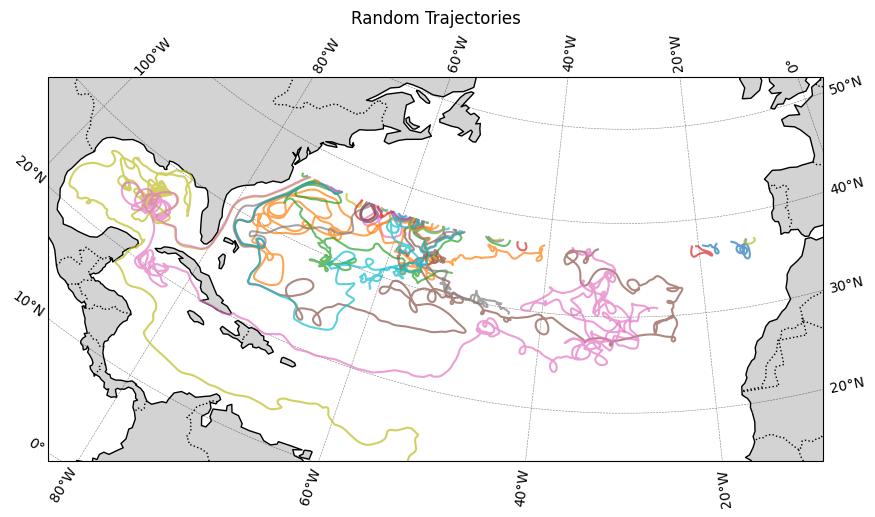

In [ ]:
#Map setup for random trajectories
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = traj_geo_1990_2000.data

# Pick random trajectories
ids = df.select("id").unique().to_series().to_numpy()

# subset ids

#ids = (df.filter(pl.col("lat").list.max() > 60).get_column("id").to_numpy())

ids_plot = np.random.choice(ids, size=50, replace=False)
#ids_plot = ids[::10][:5]

df_sub = df.filter(pl.col("id").is_in(ids_plot))

# Explode the lists to get individual points
df_exploded = df_sub.select(["id", "lon", "lat"]).explode(["lon", "lat"])

def setup_map(ax):
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      linewidth=0.4, alpha=0.5, linestyle='--', color='black')
    ax.set_extent([-92, -10, 13, 40])  # SPG region

# Create figure and map axes
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-30, central_latitude=50)})
setup_map(ax)

# Plot trajectories
for tid in ids_plot:
    dfi = df_exploded.filter(pl.col("id") == tid)
    ax.plot(
        dfi["lon"].to_numpy(),
        dfi["lat"].to_numpy(),
        alpha=0.7,
        transform=ccrs.PlateCarree()
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Trajectories")
plt.show()

In [ ]:
# Makind TrajFrame from Parquet file
import polars as pl
import lt_toolbox as ltt

# Load Parquet
traj_filepath = "/work/scratch-pw5/evanh/project_1m/eORCA12/eORCA12_output/ORCA12_NPD_2000_2009_1m_run.parquet"
dataset = pl.read_parquet(traj_filepath, use_pyarrow=True)

# Create condensed TrajFrame
traj = ltt.TrajFrame(source=dataset, condense=True)

# Convert time to datetime
traj_geo = traj.use_datetime(start_date='2000-01-01', unit='s')

lon_mdl = t12.nav_lon.values
lat_mdl = t12.nav_lat.values
depth_mdl = t12.deptht.values

# Provide the model grid for interpolation
# lon_mdl, lat_mdl, depth_mdl must be your ORCA12 arrays
traj_geo_2000_2009 = traj_geo.transform_trajectory_coords(lon=lon_mdl, lat=lat_mdl, depth=depth_mdl)

# After this, traj_geo.data will contain the interpolated lat/lon/depth as lists
traj_geo_2000_2009


<TrajFrame object>

----- Trajectory DataFrame -----
Trajectories: 279397
Variables: ['id', 'lon', 'lat', 'depth', 'subvol', 'time', 'boxface', 'somxl010', 'hfds', 'thetao_con', 'so_abs']
<bound method DataFrame.glimpse of shape: (279_397, 11)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id     ┆ lon        ┆ lat        ┆ depth     ┆ … ┆ somxl010  ┆ hfds      ┆ thetao_co ┆ so_abs    │
│ ---    ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ n         ┆ ---       │
│ i64    ┆ list[f64]  ┆ list[f64]  ┆ list[f64] ┆   ┆ list[f64] ┆ list[f64] ┆ ---       ┆ list[f64] │
│        ┆            ┆            ┆           ┆   ┆           ┆           ┆ list[f64] ┆           │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1      ┆ [-74.11746 ┆ [36.75345, ┆ [1.030808 ┆ … ┆ [61.64,   ┆ [-496.19, ┆ [17.56,   ┆ [35.9,    │
│        ┆ 2, -74.075 ┆ 36.755232, ┆ ,         ┆ 

In [4]:
#Map setup for random trajectories
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = traj_geo_2000_2009.data

# Pick random trajectories
ids = df.select("id").unique().to_series().to_numpy()

# subset ids

#ids = (df.filter(pl.col("lat").list.max() > 60).get_column("id").to_numpy())

ids_plot = np.random.choice(ids, size=50, replace=False)
#ids_plot = ids[::10][:5]

df_sub = df.filter(pl.col("id").is_in(ids_plot))

# Explode the lists to get individual points
df_exploded = df_sub.select(["id", "lon", "lat"]).explode(["lon", "lat"])

def setup_map(ax):
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      linewidth=0.4, alpha=0.5, linestyle='--', color='black')
    ax.set_extent([-75, 5, 28, 65])  # SPG region

# Create figure and map axes
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-30, central_latitude=50)})
setup_map(ax)

# Plot trajectories
for tid in ids_plot:
    dfi = df_exploded.filter(pl.col("id") == tid)
    ax.plot(
        dfi["lon"].to_numpy(),
        dfi["lat"].to_numpy(),
        alpha=0.7,
        transform=ccrs.PlateCarree()
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Trajectories")
plt.show()

NameError: name 'traj_geo_2000_2009' is not defined